In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

In [ ]:
# Load dataset
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
X = df.drop("PE" , axis=1)
y = df["PE"]

In [5]:
# Split out the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)


In [6]:
df.shape

(9568, 5)

In [7]:
# Standardised the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# convert dataset to tensores
import torch
import torch.nn as nn
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype =torch.float32 ).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype =torch.float32 ).view(-1,1)


In [17]:
from torch.utils.data import TensorDataset, DataLoader
# Load the Tensor datasets
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

# load the data loader
train_loader = DataLoader(train_dataset , batch_size = 32, shuffle=True)
test_loader = DataLoader(test_dataset , batch_size = 32)

In [25]:


# Define ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [26]:
import torch.optim as optim
model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [27]:
# Training a model

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader: 
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()  
        outputs = model(xb)    # forward prop ... predicted ouputes fro this batch
        loss = crietron(outputs, yb)   # compute loss
        loss.backward() #backward prop ... compute gradient
        optimizer.step()  #params update

        running_loss += loss.item()  #loss in tensor -> py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():  #No gradient compute
        for xb, yb in test_loader:
            outputs = model(xb) 
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1} / {epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1 / 100 ==> train loss = 206035.53824626867 & val loss = 204491.0983270202
epoch 2 / 100 ==> train loss = 199087.83978544775 & val loss = 191304.45438762626
epoch 3 / 100 ==> train loss = 177166.38207400497 & val loss = 161027.13368055556
epoch 4 / 100 ==> train loss = 140376.02254353234 & val loss = 120463.30082070707
epoch 5 / 100 ==> train loss = 101054.61571050996 & val loss = 84939.03022411616
epoch 6 / 100 ==> train loss = 72138.44476834577 & val loss = 62324.962160669194
epoch 7 / 100 ==> train loss = 54124.307738650496 & val loss = 46866.690459280304
epoch 8 / 100 ==> train loss = 40099.387583566546 & val loss = 33490.36797664141
epoch 9 / 100 ==> train loss = 27566.691624883395 & val loss = 21892.712614425505
epoch 10 / 100 ==> train loss = 17241.2207517102 & val loss = 12975.301560527147
epoch 11 / 100 ==> train loss = 9950.759644162003 & val loss = 7532.822423453283
epoch 12 / 100 ==> train loss = 6081.7981236396145 & val loss = 5000.984135791509
epoch 13 / 100 ==> tra

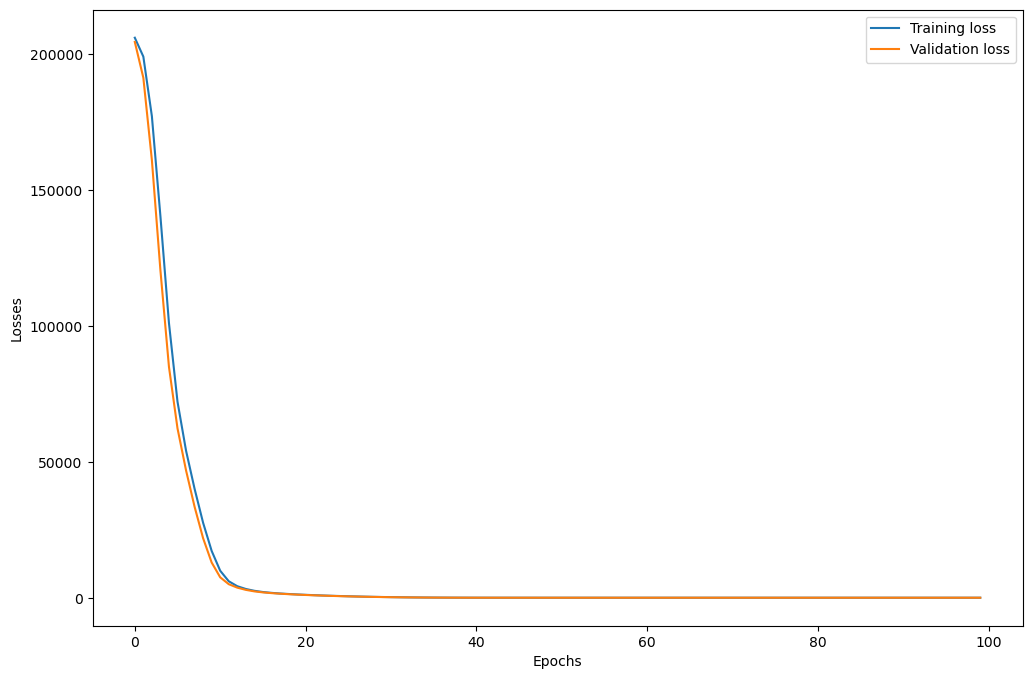

In [28]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training loss": train_losses,
    "Validation loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training loss"], label = "Training loss")
plt.plot(loss_df["Validation loss"], label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [24]:
# Loading the BEST MODEL
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [31]:
# Evalute the model
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.176679611206055
Testing MSE: 20.40390396118164


In [32]:
from sklearn.metrics import r2_score

print("r^2:", r2_score(y_test, test_preds))

r^2: 0.9296006530305763


In [35]:
# Compaire actual values vs Predicted Values
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual values"])
pd.concat([predicted_df,actual_df], axis = 1)

,Predicted values,Actual values
0,435.685181,433.27
1,437.304321,438.16
2,461.284576,458.42
3,475.853516,480.82
4,436.102203,441.41
...,...,...
3153,466.185272,468.45
3154,483.002106,485.24
3155,478.786255,482.83
3156,474.465485,479.14
